<a href="https://colab.research.google.com/github/flyingrockingit/Module-11/blob/main/Recommendation_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
files = files.upload ()

Saving ratings.csv to ratings.csv
Saving movies.csv to movies.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

In [4]:
rating_df = pd.read_csv('ratings.csv')
rating_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
movies_df = pd.read_csv('movies.csv')
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
movies_df['year' ] = movies_df.title. str.extract('(\(\d\d\d\d\))',expand =True)
movies_df.head()

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_9298/334834283.py:1: SyntaxWarning: invalid escape sequence '\('
  movies_df['year' ] = movies_df.title. str.extract('(\(\d\d\d\d\))',expand =True)


,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,(1995)
1,2,Jumanji (1995),Adventure|Children|Fantasy,(1995)
2,3,Grumpier Old Men (1995),Comedy|Romance,(1995)
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,(1995)
4,5,Father of the Bride Part II (1995),Comedy,(1995)


In [7]:
movies_df['year'] = movies_df.year.str.extract('(\d\d\d\d)', expand=True)
movies_df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9298/3832456347.py:1: SyntaxWarning: invalid escape sequence '\d'
  movies_df['year'] = movies_df.year.str.extract('(\d\d\d\d)', expand=True)


,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II (1995),Comedy,1995


In [8]:
movies_df['title' ] = movies_df['title'].str.replace(r'\s*\(\d{4}\)', '',
regex=True).str.strip()
movies_df.head()

,movieId,title,genres,year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji,Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men,Comedy|Romance,1995
3,4,Waiting to Exhale,Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II,Comedy,1995


In [9]:
movies_df['title' ] = movies_df['title' ]. apply(lambda x: x. strip())

In [10]:
movies_df['genres' ] = movies_df.genres.str.split('|')
movies_df.head()

,movieId,title,genres,year
0,1,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",1995
1,2,Jumanji,"[Adventure, Children, Fantasy]",1995
2,3,Grumpier Old Men,"[Comedy, Romance]",1995
3,4,Waiting to Exhale,"[Comedy, Drama, Romance]",1995
4,5,Father of the Bride Part II,[Comedy],1995


In [11]:
movies_copy = movies_df. copy()
for index, row in movies_df.iterrows():
  for genre in row['genres']:
    movies_copy.at[index, genre] = 1

movies_copy.head()

,movieId,title,genres,year,Adventure,Animation,Children,Comedy,Fantasy,Romance,...,Horror,Mystery,Sci-Fi,War,Musical,Documentary,IMAX,Western,Film-Noir,(no genres listed)
0,1,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",1995,1.0,1.0,1.0,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Jumanji,"[Adventure, Children, Fantasy]",1995,1.0,NaN,1.0,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Grumpier Old Men,"[Comedy, Romance]",1995,NaN,NaN,NaN,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Waiting to Exhale,"[Comedy, Drama, Romance]",1995,NaN,NaN,NaN,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Father of the Bride Part II,[Comedy],1995,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
movies_copy = movies_copy.fillna(0)
movies_copy.head()

,movieId,title,genres,year,Adventure,Animation,Children,Comedy,Fantasy,Romance,...,Horror,Mystery,Sci-Fi,War,Musical,Documentary,IMAX,Western,Film-Noir,(no genres listed)
0,1,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",1995,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Jumanji,"[Adventure, Children, Fantasy]",1995,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Grumpier Old Men,"[Comedy, Romance]",1995,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Waiting to Exhale,"[Comedy, Drama, Romance]",1995,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Father of the Bride Part II,[Comedy],1995,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
rating_df = pd.read_csv('ratings.csv')
rating_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [14]:
ratings_df = rating_df.drop(['timestamp'], axis=1)
ratings_df.head()

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


In [15]:
user_input = [
              {'title' : 'Grand Slam', 'rating' : 5.6},
              {'title' : 'Zero', 'rating' : 7},
              {'title' : 'Jumanji', 'rating' : 8.5},
              {'title' : 'Toy Story', 'rating' : 4.5}
]

movies_input = pd.DataFrame(user_input)
movies_input

,title,rating
0,Grand Slam,5.6
1,Zero,7.0
2,Jumanji,8.5
3,Toy Story,4.5


In [16]:
input_id = movies_df[movies_df['title'].isin(movies_input['title'].tolist())]
movies_input = pd.merge(input_id, movies_input)
movies_input

,movieId,title,genres,year,rating
0,1,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",1995,4.5
1,2,Jumanji,"[Adventure, Children, Fantasy]",1995,8.5


In [17]:
movies_input = movies_input.drop(['genres','year'], axis=1)
movies_input

,movieId,title,rating
0,1,Toy Story,4.5
1,2,Jumanji,8.5


In [18]:
movies_user = movies_copy[movies_copy['movieId'].isin(movies_input['movieId'].
tolist())]
movies_user

,movieId,title,genres,year,Adventure,Animation,Children,Comedy,Fantasy,Romance,...,Horror,Mystery,Sci-Fi,War,Musical,Documentary,IMAX,Western,Film-Noir,(no genres listed)
0,1,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",1995,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Jumanji,"[Adventure, Children, Fantasy]",1995,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
movies_user = movies_user.reset_index(drop=True)
movies_user

,movieId,title,genres,year,Adventure,Animation,Children,Comedy,Fantasy,Romance,...,Horror,Mystery,Sci-Fi,War,Musical,Documentary,IMAX,Western,Film-Noir,(no genres listed)
0,1,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",1995,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Jumanji,"[Adventure, Children, Fantasy]",1995,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
UserGenreTable = movies_user.drop(['movieId','title' ,'genres' ,'year' ], axis=1)
UserGenreTable

,Adventure,Animation,Children,Comedy,Fantasy,Romance,Drama,Action,Crime,Thriller,Horror,Mystery,Sci-Fi,War,Musical,Documentary,IMAX,Western,Film-Noir,(no genres listed)
0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
UserGenreTable = movies_user.drop(['movieId','title','genres','year'], axis=1)
UserProfile = UserGenreTable.transpose().dot(movies_input['rating'])

In [23]:
GenreTable = movies_copy.set_index(movies_copy['movieId'])
GenreTable = GenreTable.drop(['movieId','title','genres','year'], axis=1)

In [32]:
Recommendation_df = ((GenreTable * UserProfile).sum(axis=1)) / UserProfile.sum()

In [33]:
Recommendation_df = Recommendation_df.sort_values(ascending=False)

In [27]:
Recommendation_df = ((GenreTable * UserProfile).sum(axis=1)) / UserProfile.sum()

In [28]:
RecommendationTable = movies_df.loc[
    movies_df['movieId'].isin(Recommendation_df.head(20).keys())
]

RecommendationTable.head(10)

,movieId,title,genres,year
0,1,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",1995
1,2,Jumanji,"[Adventure, Children, Fantasy]",1995
2,3,Grumpier Old Men,"[Comedy, Romance]",1995
3,4,Waiting to Exhale,"[Comedy, Drama, Romance]",1995
4,5,Father of the Bride Part II,[Comedy],1995
5,6,Heat,"[Action, Crime, Thriller]",1995
6,7,Sabrina,"[Comedy, Romance]",1995
7,8,Tom and Huck,"[Adventure, Children]",1995
8,9,Sudden Death,[Action],1995
9,10,GoldenEye,"[Action, Adventure, Thriller]",1995


In [29]:
print(RecommendationTable[['title', 'year']].head(10))

                         title  year
0                    Toy Story  1995
1                      Jumanji  1995
2             Grumpier Old Men  1995
3            Waiting to Exhale  1995
4  Father of the Bride Part II  1995
5                         Heat  1995
6                      Sabrina  1995
7                 Tom and Huck  1995
8                 Sudden Death  1995
9                    GoldenEye  1995


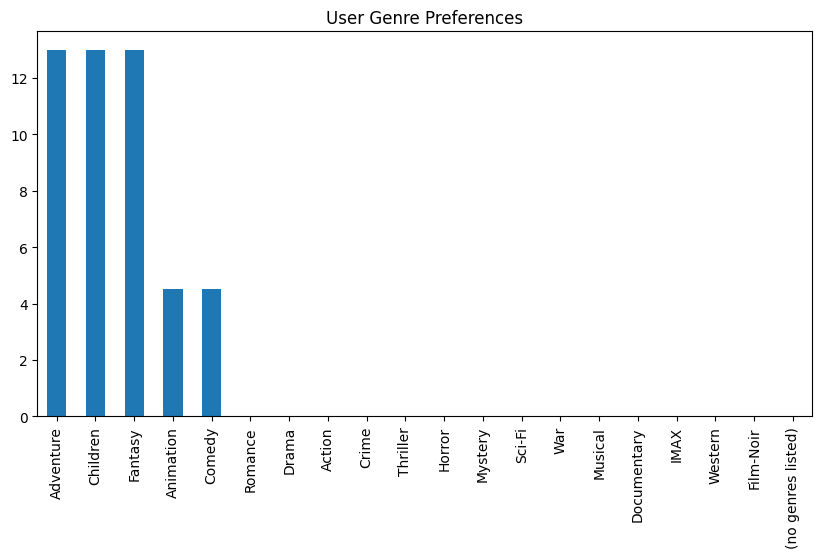

In [30]:
UserProfile.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("User Genre Preferences")
plt.show()